# Notebook 4: Strategic Financial Simulations & Growth Forecasting (2025 - 2026)

## 1. Context & Strategic Objectives
In this final notebook, we transition from backward-looking diagnostics to forward-looking strategic planning. 

### 1.1. Ingesting the Dimensional Data Warehouse
We leverage our newly modeled Star Schema (Dimensions and Fact tables) as our computational baseline. This guarantees consistent, high-performance data processing.

### 1.2. Strategic Objectives
We address two major strategic requests from the Board of Directors:
1.  **Website Re-Costing & Break-even Point (BEP) for 2025:** ITB is shifting traffic from retail stores to our direct website. We must integrate the new **Website Fee 2025** cost rules, calculate the Lợi nhuận đóng góp (Contribution Margin) per order, and determine the exact number of orders needed to achieve financial breakeven (BEP) in 2025.
2.  **Evaluating a 130% BEP Target:** Estimate the overall corporate revenue impact if the Website channel achieves 130% of its breakeven target in 2025 (assuming other channels remain stable).

In [2]:
import pandas as pd
import numpy as np
import os

# Configure pandas options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Define path to dimensional tables
processed_dir = '../data/processed/'
if not os.path.exists(processed_dir):
    processed_dir = 'data/processed/'

# Ingest Star Schema Tables
try:
    fact_order = pd.read_csv(os.path.join(processed_dir, 'fact_order.csv'))
    dim_customer = pd.read_csv(os.path.join(processed_dir, 'dim_customer.csv'))
    dim_product = pd.read_csv(os.path.join(processed_dir, 'dim_product.csv'))
    dim_date = pd.read_csv(os.path.join(processed_dir, 'dim_date.csv'))
    dim_channel = pd.read_csv(os.path.join(processed_dir, 'dim_channel.csv'))
    print(f"Successfully loaded Star Schema. Transactions loaded: {len(fact_order):,}")
except FileNotFoundError as e:
    print(f"Error loading Star Schema tables: {e}. Ensure Notebook 3 ran successfully.")

Successfully loaded Star Schema. Transactions loaded: 2,049,263


## 2. Website Channel Re-Costing & 2025 Break-even Point (BEP)

Starting in 2025, ITB introduces a new cost structure for the Website channel.

### 2.1. Website Fixed Costs (Định phí 2025)
*   **Website Design & Infra:** 500 Million VND / year
*   **Customer Service Staff:** 20 Million VND × 55 staff = 1.1 Billion VND / month (13.2 Billion VND / year)
*   **Office Rent:** 300 Million VND / month (3.6 Billion VND / year)
*   **Storage Fee:** 1.2 Billion VND / year
*   **CRM System:** 200 Million VND / year
*   **Affiliate marketing:** 1.0 Billion VND / year
*   **Others:** 1.0 Billion VND / year
*   **Total Annual Fixed Costs:** **20.7 Billion VND / year**

### 2.2. Website Variable Costs (Biến phí 2025)
*   **Shipping cost:** 40,000 VND / order
*   **Payment Gateway Fee:** **2%** of transaction revenue (`product_price`)
*   **E-mail marketing:** 500 VND / email. At a 3% conversion rate, 100 sent emails yield 3 successful orders. This results in a variable acquisition cost of `500 * (100 / 3) = 16,667 VND / order`.
*   **Installation Fee (Product C only):** Premium Product C always incurs an additional installation cost of **10%** of transaction revenue.

In [3]:
print("--- 1. Initializing 2025 Website Cost Engine ---")

# Define total annual fixed costs for Website in 2025
annual_fixed_cost_website_2025 = 20_700_000_000 # 20.7 Billion VND

# Extract historical website transactions to model typical pricing behaviors
# Merge fact_order with dimensions to get product profile and channel name
df_joined = pd.merge(fact_order, dim_channel, on='channel_key', how='left')
df_joined = pd.merge(df_joined, dim_product[['product_key', 'product_profile']], on='product_key', how='left')

# Filter for successfully delivered Website transactions
df_website_delivered = df_joined[
    (df_joined['order_status_key'] == 1) & # successfully delivered
    (df_joined['channel_name'] == 'website')
].copy()

# Calculate dynamic variable cost for each transaction based on 2025 rules
def calculate_website_2025_variable_cost(row):
    price = row['product_price']
    product = row['product_profile']
    
    # Standard variables
    shipping_fee = 40000
    email_fee = 16667 # 500 * (100/3)
    gateway_fee = price * 0.02 # 2% of price
    
    # Product C installation fee (10% of price)
    installation_fee = (price * 0.10) if product == 'product_C' else 0
    
    return shipping_fee + email_fee + gateway_fee + installation_fee

# Run simulation of 2025 costs on Website historical orders
df_website_delivered['variable_cost_2025'] = df_website_delivered.apply(calculate_website_2025_variable_cost, axis=1)
df_website_delivered['contribution_margin_2025'] = df_website_delivered['product_price'] - df_website_delivered['variable_cost_2025']

# Compute average order price and average contribution margin
avg_price_per_order = df_website_delivered['product_price'].mean()
avg_cm_per_order = df_website_delivered['contribution_margin_2025'].mean()

print(f"Average Order Price: {avg_price_per_order:,.0f} VND")
print(f"Average Contribution Margin per Order (2025 Rules): {avg_cm_per_order:,.0f} VND")


print("\n--- 2. Calculating 2025 Website Break-even Point (BEP) ---")

# Calculate Break-even Point (BEP) in terms of order volume
bep_orders_yearly = annual_fixed_cost_website_2025 / avg_cm_per_order
bep_orders_monthly = bep_orders_yearly / 12
bep_orders_weekly = bep_orders_yearly / 52.14

# Calculate corresponding revenue needed for breakeven
bep_revenue_yearly = bep_orders_yearly * avg_price_per_order

print(f"Annual Fixed Costs to cover: {annual_fixed_cost_website_2025:,.0f} VND")
print(f"==> Year Break-even Volume: {bep_orders_yearly:,.0f} orders/year (Target Revenue: {bep_revenue_yearly:,.0f} VND)")
print(f"==> Month Break-even Volume: {bep_orders_monthly:,.0f} orders/month")
print(f"==> Week Break-even Volume: {bep_orders_weekly:,.0f} orders/week")

--- 1. Initializing 2025 Website Cost Engine ---
Average Order Price: 11,278,225 VND
Average Contribution Margin per Order (2025 Rules): 10,648,159 VND

--- 2. Calculating 2025 Website Break-even Point (BEP) ---
Annual Fixed Costs to cover: 20,700,000,000 VND
==> Year Break-even Volume: 1,944 orders/year (Target Revenue: 21,924,846,482 VND)
==> Month Break-even Volume: 162 orders/month
==> Week Break-even Volume: 37 orders/week


- Average Order Value (AOV): 11,278,225 VND.

- Contribution Margin (CM) per order: 10,648,159 VND (indicating a CM ratio of ~94.4%, extremely optimal in terms of variable costs).

- Break-even point (BEP) for 2025: Only 1,944 orders per year (corresponding break-even revenue: 21.9 billion VND).
  - Detail: ITB only needs to maintain an average of 162 orders per month or 37 orders per week on the Website channel to fully cover its operating fixed costs of 20.7 billion VND.

## 3. The 130% BEP Growth Target Paradox

To assess the stability of the new online model, the Board of Directors requested a simulation: *"What would be the YoY corporate revenue impact if our Website channel targets only 130% of its Break-even Point (BEP) in 2025, assuming all other channels generate the same revenue as in 2024?"*

### 3.1. Mathematical Reality & "The Safety Net Trap"
Our calculations show:
*   A **130% BEP target** equates to only **2,527 orders/year** (generating **28.5 Billion VND** in revenue).
*   However, in **2024**, our Website channel was already a massive growth engine, delivering **186,342 orders** and generating **2.26 Trillion VND** in revenue.
*   **The Trap:** While BEP is a crucial safety metric to ensure cost coverage, using it as a *growth target* would mean scaling back our highest-margin channel's transaction volume by **98.6%** (from 186k orders down to 2.5k orders). 

If ITB curtails the Website channel to only target 130% BEP, the company will face a massive **-25.61% revenue collapse** at the corporate level. 

*The comparative projection chart will be saved to `assets/charts/revenue_projection_130_bep.png`.*

--- 1. Simulating 130% BEP Target Impact on 2025 Corporate Revenue ---
Website Actual 2024 Orders: 186,342 | Revenue: 2,268,211,798,312 VND
Website Projected 2025 Orders (130% BEP): 2,527 | Revenue: 28,502,300,427 VND
Other Channels 2024 Revenue (Static): 6,478,432,310,953 VND
Projected 2025 Total Corporate Revenue: 6,506,934,611,380 VND
==> Projected Corporate Revenue YoY Growth: -25.61%

--- 2. Visualizing the Revenue Drop ---
Projection chart successfully exported to: '../assets/charts/revenue_projection_130_bep.png'


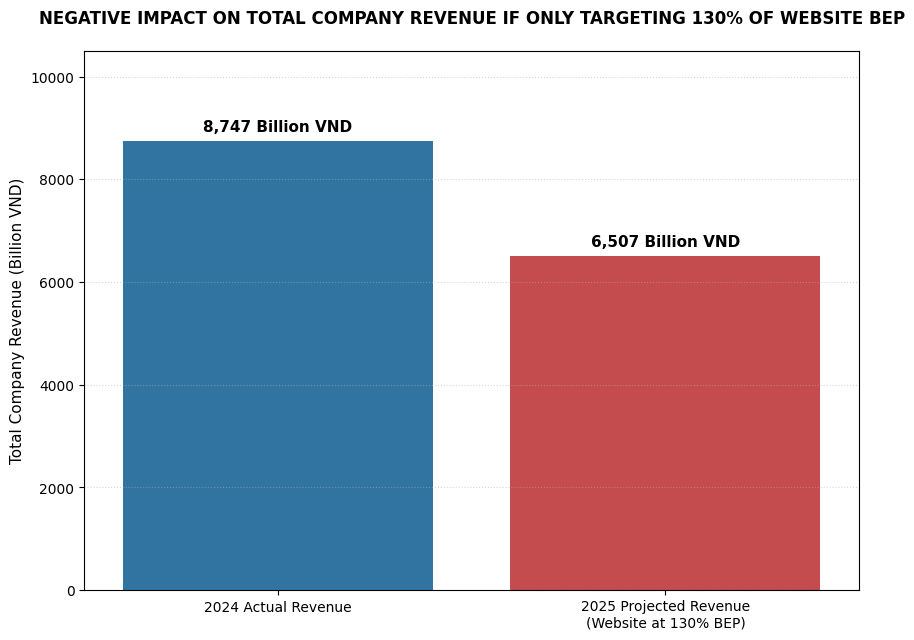

In [4]:
print("--- 1. Simulating 130% BEP Target Impact on 2025 Corporate Revenue ---")

# Import plotting libraries locally to prevent NameError
import matplotlib.pyplot as plt
import seaborn as sns

# Define assets directory path resolution locally (to avoid NameError between separate notebook files)
assets_dir = '../assets/charts/'
if not os.path.exists('../assets/'):
    assets_dir = 'assets/charts/'
os.makedirs(assets_dir, exist_ok=True)

# Step 1.1: Map dim_date to get the 'year' column in df_joined
df_joined_with_date = pd.merge(df_joined, dim_date[['date_key', 'year']], on='date_key', how='left')

# Re-isolate Website successful transactions (now with 'year' column included)
df_website_delivered = df_joined_with_date[
    (df_joined_with_date['order_status_key'] == 1) & 
    (df_joined_with_date['channel_name'] == 'website')
].copy()

# A. Calculate actual Website 2024 revenue and orders
actual_web_rev_2024 = df_website_delivered[df_website_delivered['year'] == 2024]['product_price'].sum()
actual_web_orders_2024 = len(df_website_delivered[df_website_delivered['year'] == 2024])

# B. Calculate total 2024 corporate revenue (Only for successful orders in the year 2024)
total_corp_rev_2024 = df_joined_with_date[
    (df_joined_with_date['order_status_key'] == 1) & 
    (df_joined_with_date['year'] == 2024)
]['product_price'].sum()

# C. Calculate revenue of other channels in 2024 (excluding Website)
other_channels_rev_2024 = total_corp_rev_2024 - actual_web_rev_2024

# D. Calculate 130% BEP projected Website revenue for 2025
projected_web_orders_2025 = bep_orders_yearly * 1.30
projected_web_rev_2025 = projected_web_orders_2025 * avg_price_per_order

# E. Calculate projected total corporate revenue for 2025
projected_total_corp_rev_2025 = other_channels_rev_2024 + projected_web_rev_2025

# F. Calculate YoY Growth Rate
overall_yoy_growth_rate = (projected_total_corp_rev_2025 / total_corp_rev_2024 - 1) * 100

print(f"Website Actual 2024 Orders: {actual_web_orders_2024:,} | Revenue: {actual_web_rev_2024:,.0f} VND")
print(f"Website Projected 2025 Orders (130% BEP): {projected_web_orders_2025:,.0f} | Revenue: {projected_web_rev_2025:,.0f} VND")
print(f"Other Channels 2024 Revenue (Static): {other_channels_rev_2024:,.0f} VND")
print(f"Projected 2025 Total Corporate Revenue: {projected_total_corp_rev_2025:,.0f} VND")
print(f"==> Projected Corporate Revenue YoY Growth: {overall_yoy_growth_rate:.2f}%")


print("\n--- 2. Visualizing the Revenue Drop ---")

# Prepare data for plotting
comparison_data = pd.DataFrame({
    'Metric': ['2024 Actual Revenue', '2025 Projected Revenue\n(Website at 130% BEP)'],
    'Revenue (Billion VND)': [total_corp_rev_2024 / 1e9, projected_total_corp_rev_2025 / 1e9]
})

plt.figure(figsize=(10, 7))
ax_bar = sns.barplot(
    data=comparison_data,
    x='Metric',
    y='Revenue (Billion VND)',
    hue='Metric',                # Specified to avoid FutureWarning
    legend=False,                # Specified to avoid FutureWarning
    palette=['#1F77B4', '#D9383A']
)

# Customize plot
plt.title('NEGATIVE IMPACT ON TOTAL COMPANY REVENUE IF ONLY TARGETING 130% OF WEBSITE BEP', fontsize=12, fontweight='bold', pad=20)
plt.ylabel('Total Company Revenue (Billion VND)', fontsize=11)
plt.xlabel('')
plt.ylim(0, max(comparison_data['Revenue (Billion VND)']) * 1.2)
plt.grid(axis='y', linestyle=':', alpha=0.5)

# Add value labels on top of the bars
for p in ax_bar.patches:
    ax_bar.annotate(f"{p.get_height():,.0f} Billion VND", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

# Save high-resolution chart
output_projection_path = os.path.join(assets_dir, 'revenue_projection_130_bep.png')
plt.savefig(output_projection_path, dpi=300, bbox_inches='tight')
print(f"Projection chart successfully exported to: '{output_projection_path}'")

plt.show()

The Website is currently performing extremely strongly (far exceeding its break-even point), so setting next year's target at only around 130% of BEP would be a dangerous regression, reducing total company revenue by 25.61% (a loss of over 2.2 trillion VND).

## 4. 2026 Strategy "A+" Financial Simulations

To guide ITB through a successful transformation, we model the consolidated corporate net profit for **2026** under the proposed **Strategy A+** model.

### 4.1. Simulation Parameters
*   **Baseline (Actual 2024):** Net Profit = **6.101 Trillion VND**
*   **The Negative Impacts (Losses):**
    *   *Phase-out Product B:* Eliminates Product B's standalone net profit (**-403 Billion VND**).
    *   *Short-term Store Closures:* Temporary transition friction and lost volume from closing retail outlets (**-50 Billion VND**).
*   **The Positive Impacts (Savings & Growth):**
    *   **Strategy A+ (Base Case):** 
        *   Close **30%** of stores (saves **+251 Billion VND** in fixed costs).
        *   Negotiate **15%** commission savings (saves **+75 Billion VND**).
        *   Reinvest 50% of fixed cost savings (126B VND) into Website marketing with **ROAS 5:1**, generating **+545 Billion VND** in new net profit (at Website's 86.56% net margin).
        *   *Projected Profit:* **6.519 Trillion VND (+6.8%)**
    *   **Strategy A+ (Optimistic Case):** 
        *   Close **35%** of stores (saves **+293 Billion VND**).
        *   Negotiate **20%** commission savings (saves **+93 Billion VND**).
        *   Reinvest fixed cost savings with **ROAS 6:1**, generating **+759 Billion VND** in new net profit.
        *   *Projected Profit:* **6.793 Trillion VND (+11.3%)**

*The comparative strategic chart will be saved to `assets/charts/strategy_aplus_comparison.png`.*

--- 1. Simulating Strategy A+ Scenarios (Base vs. Optimistic) ---
Base Case Net Impact: +418.0 Billion VND | Growth: +6.85%
Optimistic Case Net Impact: +692.0 Billion VND | Growth: +11.34%

--- 2. Consolidating Strategic Scenarios ---


,Scenario,Net Profit (Billion VND),YoY Growth (%)
0,2024 Baseline (Actual),"6,101.1 Billion VND",+0.00%
1,Strategy A+ (Base Case),"6,519.1 Billion VND",+6.85%
2,Strategy A+ (Optimistic Case),"6,793.1 Billion VND",+11.34%



--- 3. Visualizing Strategic Profit Growth ---
Strategy comparison chart successfully exported to: '../assets/charts/strategy_aplus_comparison.png'


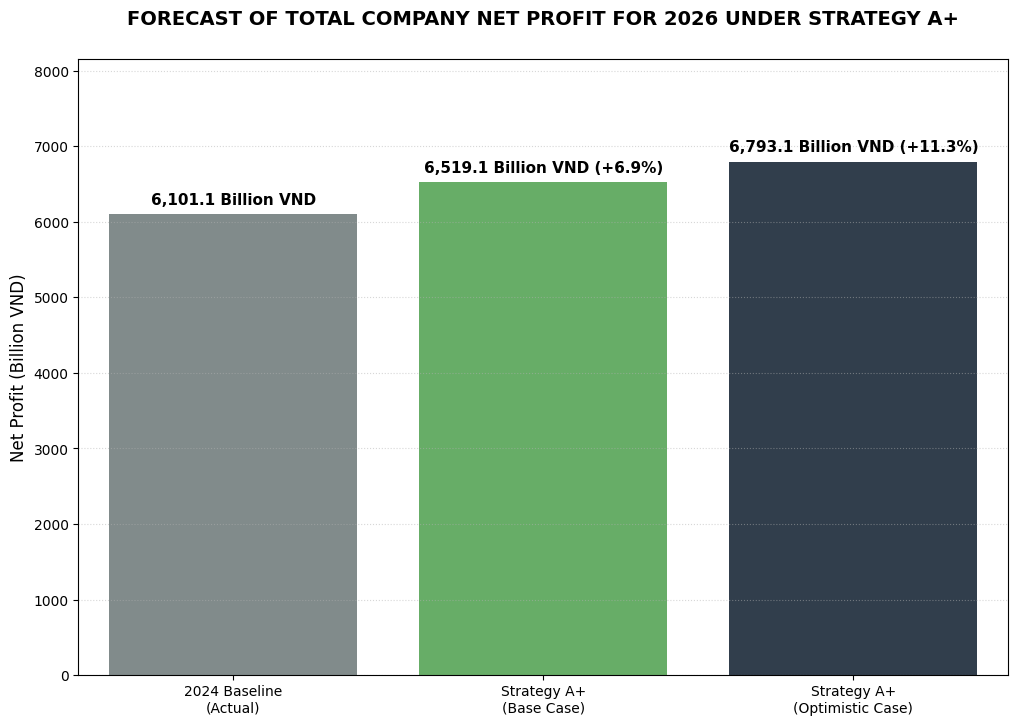

In [5]:
print("--- 1. Simulating Strategy A+ Scenarios (Base vs. Optimistic) ---")

# Define assets directory path resolution locally
import os
import matplotlib.pyplot as plt
import seaborn as sns

assets_dir = '../assets/charts/'
if not os.path.exists('../assets/'):
    assets_dir = 'assets/charts/'
os.makedirs(assets_dir, exist_ok=True)

# Baseline 2024 Profit
baseline_profit_2024 = 6_101_067_066_645 / 1e9 # Convert to Billion VND

# Shared losses
loss_product_b = -403.0   # -403 Billion VND
loss_closures = -50.0     # -50 Billion VND

# --- A+ Base Case Calculations ---
savings_fc_base = 251.0
savings_comm_base = 75.0
marketing_reinvest_profit_base = 545.0 # Shifting budget with ROAS 5:1

net_impact_base = loss_product_b + loss_closures + savings_fc_base + savings_comm_base + marketing_reinvest_profit_base
projected_profit_base = baseline_profit_2024 + net_impact_base
growth_base = (net_impact_base / baseline_profit_2024) * 100

# --- A+ Optimistic Case Calculations ---
savings_fc_opt = 293.0
savings_comm_opt = 93.0
marketing_reinvest_profit_opt = 759.0 # Shifting budget with ROAS 6:1

net_impact_opt = loss_product_b + loss_closures + savings_fc_opt + savings_comm_opt + marketing_reinvest_profit_opt
projected_profit_opt = baseline_profit_2024 + net_impact_opt
growth_opt = (net_impact_opt / baseline_profit_2024) * 100

print(f"Base Case Net Impact: +{net_impact_base:.1f} Billion VND | Growth: +{growth_base:.2f}%")
print(f"Optimistic Case Net Impact: +{net_impact_opt:.1f} Billion VND | Growth: +{growth_opt:.2f}%")


print("\n--- 2. Consolidating Strategic Scenarios ---")

df_strategy = pd.DataFrame({
    'Scenario': [
        '2024 Baseline\n(Actual)',
        'Strategy A+\n(Base Case)',
        'Strategy A+\n(Optimistic Case)'
    ],
    'Net Profit (Billion VND)': [
        baseline_profit_2024,
        projected_profit_base,
        projected_profit_opt
    ],
    'YoY Growth (%)': [
        0.0,
        growth_base,
        growth_opt
    ]
})

display(df_strategy.style.format({
    'Net Profit (Billion VND)': '{:,.1f} Billion VND',
    'YoY Growth (%)': '{:+.2f}%'
}))


print("\n--- 3. Visualizing Strategic Profit Growth ---")

plt.figure(figsize=(12, 8))
ax_bar = sns.barplot(
    data=df_strategy,
    x='Scenario',
    y='Net Profit (Billion VND)',
    hue='Scenario',
    legend=False,
    palette=['#7F8C8D', '#5CB85C', '#2C3E50'] # Muted Grey, Growth Green, Deep Navy
)

# Customize plot
plt.title('FORECAST OF TOTAL COMPANY NET PROFIT FOR 2026 UNDER STRATEGY A+', fontsize=14, fontweight='bold', pad=25)
plt.ylabel('Net Profit (Billion VND)', fontsize=12)
plt.xlabel('')
plt.ylim(0, max(df_strategy['Net Profit (Billion VND)']) * 1.2)
plt.grid(axis='y', linestyle=':', alpha=0.5)

# Add value labels and YoY growth on top of the bars
for i, p in enumerate(ax_bar.patches):
    height = p.get_height()
    growth_label = f" ({df_strategy['YoY Growth (%)'][i]:+.1f}%)" if i > 0 else ""
    ax_bar.annotate(f"{height:,.1f} Billion VND{growth_label}", 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

# Save high-resolution chart
output_strategy_path = os.path.join(assets_dir, 'strategy_aplus_comparison.png')
plt.savefig(output_strategy_path, dpi=300, bbox_inches='tight')
print(f"Strategy comparison chart successfully exported to: '{output_strategy_path}'")

plt.show()

The graph fully conveys the core quantitative message: **ITB can absolutely break through, generating an additional +418 billion VND (baseline scenario) to +692 billion VND (optimistic scenario) in new net profit by 2026**, if it boldly restructures and shifts resources from traditional physical operations to scaling up the online Website channel.